In [1]:
import os
import json
import pickle
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import lightgbm as lgb

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 10


In [2]:
df = pd.read_parquet("data/dataset.parquet")
print("Shape:", df.shape)
df.head()


Shape: (145898, 71)


,Product_ID,Product_Name,Brand,Category,Subcategory,SKU,City,Date,Day_of_Week,Month,...,Festival_Impact_Score,Weather_Impact_Score,Price_Volatility_30d,Price_to_Competitor_Ratio,Stock_Days_Remaining,Demand_Momentum_7d,Revenue_Per_Unit,Price_Rank_in_Category,Fuel_Price_INR_Proxy,Optimal_Price
0,PROD-ELEC-001,Wireless Noise Cancelling Headphones Pro,SoundPulse,Electronics,Audio,SKU-ELEC-001,Ahmedabad,2023-01-15,6,1,...,3.00,0.0,0.0,0.982,3.6,1.0,1322.410034,1,110.120003,5248.950195
1,PROD-ELEC-001,Wireless Noise Cancelling Headphones Pro,SoundPulse,Electronics,Audio,SKU-ELEC-001,Ahmedabad,2023-01-16,0,1,...,0.60,0.0,0.0,0.963,3.6,1.0,1322.410034,1,110.339996,4807.669922
2,PROD-ELEC-001,Wireless Noise Cancelling Headphones Pro,SoundPulse,Electronics,Audio,SKU-ELEC-001,Ahmedabad,2023-01-17,1,1,...,0.69,0.0,0.0,1.027,4.2,1.0,1322.410034,1,111.300003,4683.220215
3,PROD-ELEC-001,Wireless Noise Cancelling Headphones Pro,SoundPulse,Electronics,Audio,SKU-ELEC-001,Ahmedabad,2023-01-18,2,1,...,0.80,0.0,0.0,1.035,4.1,1.0,1322.410034,1,110.150002,4725.430176
4,PROD-ELEC-001,Wireless Noise Cancelling Headphones Pro,SoundPulse,Electronics,Audio,SKU-ELEC-001,Ahmedabad,2023-01-19,3,1,...,0.92,0.0,0.0,1.015,4.0,1.0,1322.410034,1,111.209999,4735.279785


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 145898 entries, 0 to 145897
Data columns (total 71 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Product_ID                    145898 non-null  str    
 1   Product_Name                  145898 non-null  str    
 2   Brand                         145898 non-null  str    
 3   Category                      145898 non-null  str    
 4   Subcategory                   145898 non-null  str    
 5   SKU                           145898 non-null  str    
 6   City                          145898 non-null  str    
 7   Date                          145898 non-null  str    
 8   Day_of_Week                   145898 non-null  int8   
 9   Month                         145898 non-null  int8   
 10  Quarter                       145898 non-null  int8   
 11  Is_Weekend                    145898 non-null  bool   
 12  Is_Holiday                    145898 non-null  bool   


In [4]:
print("Null values count:", df.isna().sum().sum())
print("Duplicate rows count:", df.duplicated(subset=["Product_ID", "City", "Date"]).sum())


Null values count: 0
Duplicate rows count: 0


In [5]:
print("Funnel check (Orders <= Cart <= Clicks <= Views):")
funnel_violations = ((df["Orders"] > df["Cart_Adds"]) | (df["Cart_Adds"] > df["Clicks"]) | (df["Clicks"] > df["Views"])).sum()
print("Funnel violations:", funnel_violations)

print("Margin check (Optimal_Price >= 1.05 * Cost_Price):")
margin_violations = (df["Optimal_Price"] < (df["Cost_Price"] * 1.049)).sum()
print("Margin violations:", margin_violations)

print("Boundary check (Min_Price <= Optimal_Price <= Max_Price):")
bound_violations = ((df["Optimal_Price"] < df["Min_Allowed_Price"]) | (df["Optimal_Price"] > df["Max_Allowed_Price"])).sum()
print("Boundary violations:", bound_violations)


Funnel check (Orders <= Cart <= Clicks <= Views):
Funnel violations: 0
Margin check (Optimal_Price >= 1.05 * Cost_Price):
Margin violations: 0
Boundary check (Min_Price <= Optimal_Price <= Max_Price):
Boundary violations: 0


In [6]:
df[["Cost_Price", "Current_Price", "MRP", "Competitor_Avg_Price", "Optimal_Price"]].describe().round(2)


,Cost_Price,Current_Price,MRP,Competitor_Avg_Price,Optimal_Price
count,145898.00,145898.00,145898.00,145898.00,145898.00
mean,745.45,1230.88,1516.30,1230.84,1476.68
std,724.83,1096.26,1346.67,1101.11,1325.34
min,69.60,86.57,120.00,82.14,102.67
25%,263.56,505.30,599.00,496.40,578.81
50%,570.00,892.58,1099.00,899.01,1048.95
75%,967.56,1611.74,1999.00,1612.00,1964.48
max,5219.42,8085.23,8999.00,9037.56,9448.95


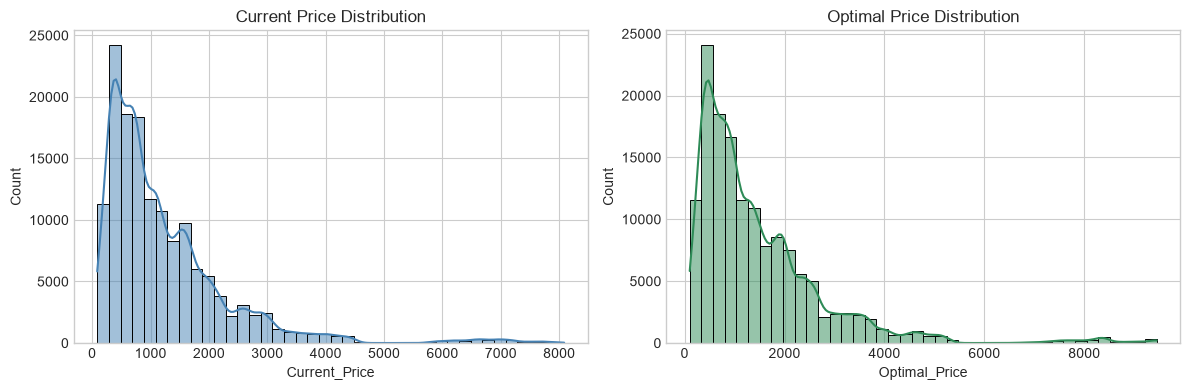

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["Current_Price"], kde=True, bins=40, ax=axes[0], color="steelblue")
axes[0].set_title("Current Price Distribution")
sns.histplot(df["Optimal_Price"], kde=True, bins=40, ax=axes[1], color="seagreen")
axes[1].set_title("Optimal Price Distribution")
plt.tight_layout()
plt.show()


In [8]:
cat_summary = df.groupby("Category").agg(
    avg_current_price=("Current_Price", "mean"),
    avg_optimal_price=("Optimal_Price", "mean"),
    avg_orders=("Orders", "mean"),
    avg_margin=("Margin_Pct", "mean")
).round(2)
cat_summary


,avg_current_price,avg_optimal_price,avg_orders,avg_margin
Category,,,,
Electronics,2833.199951,3382.899902,46.52,33.330002
Fashion,1434.390015,1676.969971,62.91,48.110001
Footwear,1723.750000,2105.919922,60.32,46.529999
Grocery,410.970001,505.230011,63.31,13.310000
Home & Kitchen,1204.449951,1477.209961,59.44,39.389999
Mobile Accessories,647.960022,738.469971,72.63,50.160000
Personal Care,553.599976,680.780029,58.81,46.000000
Sports & Fitness,839.260010,1009.909973,60.24,47.240002


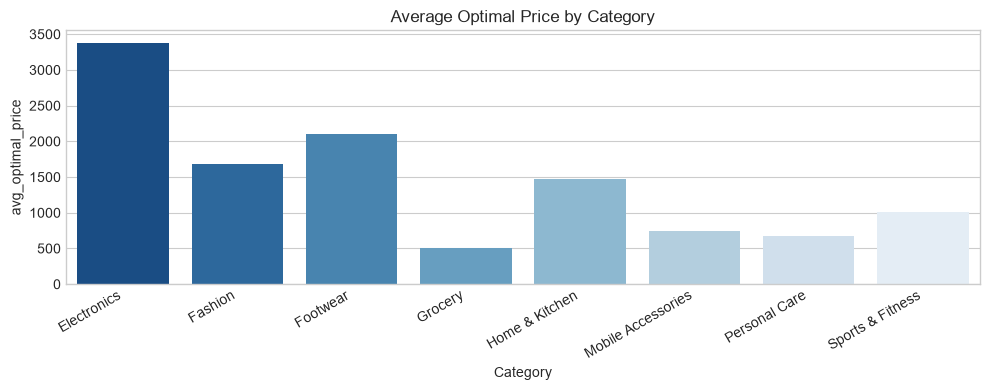

In [9]:
plt.figure(figsize=(10, 4))
sns.barplot(data=cat_summary.reset_index(), x="Category", y="avg_optimal_price", palette="Blues_r")
plt.xticks(rotation=30, ha="right")
plt.title("Average Optimal Price by Category")
plt.tight_layout()
plt.show()


In [10]:
df.groupby("City").agg(
    count=("Date", "count"),
    avg_current_price=("Current_Price", "mean"),
    avg_optimal_price=("Optimal_Price", "mean"),
    avg_views=("Views", "mean"),
    avg_orders=("Orders", "mean")
).round(2)


,count,avg_current_price,avg_optimal_price,avg_views,avg_orders
City,,,,,
Ahmedabad,72949,1230.829956,1478.329956,10979.91,66.09
Surat,72949,1230.930054,1475.040039,9101.16,54.53


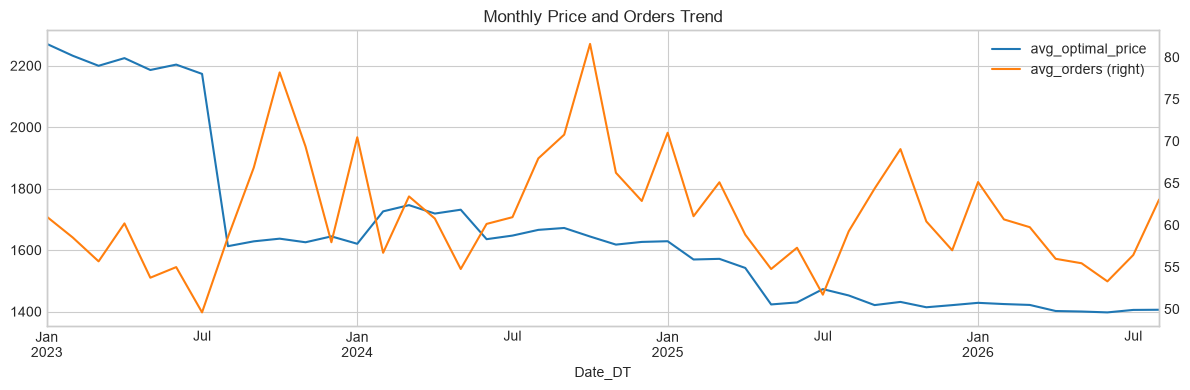

In [11]:
df["Date_DT"] = pd.to_datetime(df["Date"])
monthly = df.groupby(df["Date_DT"].dt.to_period("M")).agg(
    avg_optimal_price=("Optimal_Price", "mean"),
    avg_orders=("Orders", "mean")
)
monthly.plot(secondary_y="avg_orders", figsize=(12, 4))
plt.title("Monthly Price and Orders Trend")
plt.tight_layout()
plt.show()


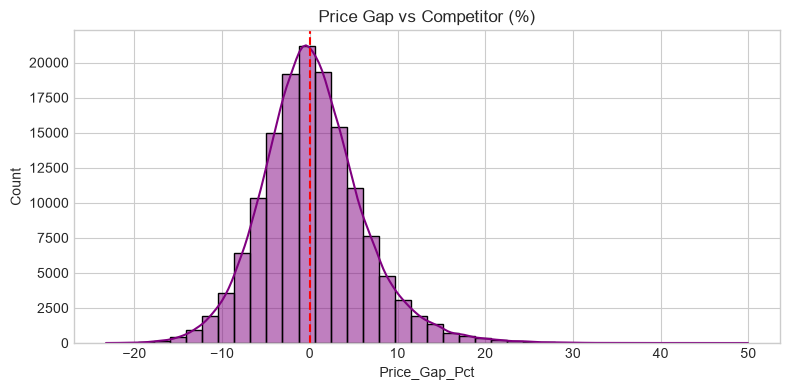

In [12]:
plt.figure(figsize=(8, 4))
sns.histplot(df["Price_Gap_Pct"], bins=40, kde=True, color="purple")
plt.axvline(0, color="red", linestyle="--")
plt.title("Price Gap vs Competitor (%)")
plt.tight_layout()
plt.show()


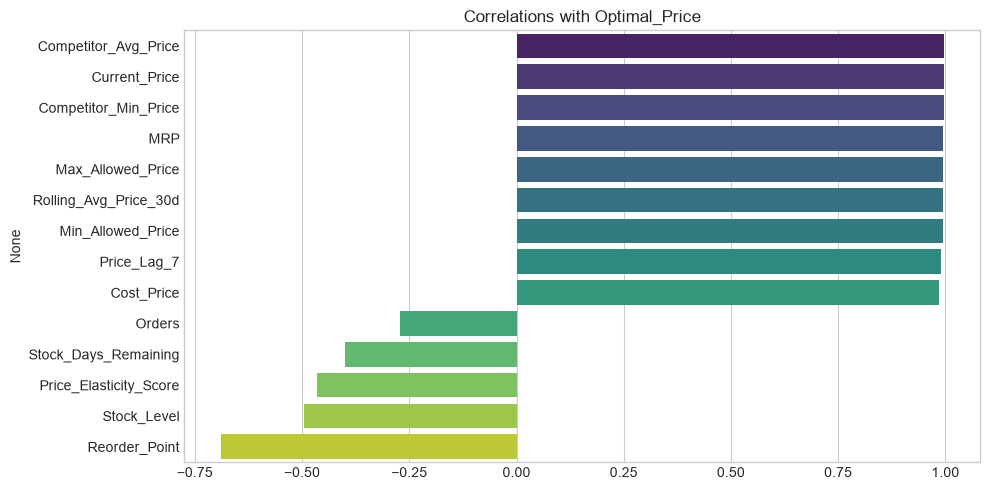

In [13]:
num_cols = df.select_dtypes(include=[np.number]).columns
corrs = df[num_cols].corr()["Optimal_Price"].sort_values(ascending=False)
top_corrs = pd.concat([corrs.head(10), corrs.tail(5)]).drop("Optimal_Price", errors="ignore")

plt.figure(figsize=(10, 5))
sns.barplot(x=top_corrs.values, y=top_corrs.index, palette="viridis")
plt.title("Correlations with Optimal_Price")
plt.tight_layout()
plt.show()


In [14]:
category_mapping = {c: i for i, c in enumerate(sorted(df["Category"].unique()))}
city_mapping = {"Ahmedabad": 0, "Surat": 1}
weather_mapping = {w: i for i, w in enumerate(sorted(df["Weather_Type"].unique()))}
competitor_stock_mapping = {"In_Stock": 0, "Low_Stock": 1, "Out_of_Stock": 2}

df["Category_Code"] = df["Category"].map(category_mapping).astype(np.int8)
df["City_Code"] = df["City"].map(city_mapping).astype(np.int8)
df["Weather_Code"] = df["Weather_Type"].map(weather_mapping).astype(np.int8)
df["Competitor_Stock_Code"] = df["Competitor_Stock_Status"].map(competitor_stock_mapping).astype(np.int8)

bool_cols = ["Is_Weekend", "Is_Holiday", "Is_Month_End", "Is_Extreme_Weather"]
for col in bool_cols:
    df[col] = df[col].astype(np.int8)


In [15]:
FEATURE_COLUMNS = [
    "Cost_Price", "Current_Price", "MRP", "Marketplace_Fee_Pct",
    "Competitor_Avg_Price", "Competitor_Min_Price", "Price_Gap_Pct", "Price_to_Competitor_Ratio",
    "Competitor_Discount_Pct", "Market_Rank", "Discount_Pct", "Margin_Pct",
    "Stock_Level", "Reorder_Point", "Lead_Time_Days", "Stock_Out_Risk", "Stock_Days_Remaining",
    "Category_Code", "City_Code", "Weather_Code", "Competitor_Stock_Code",
    "Day_of_Week", "Month", "Quarter", "Is_Weekend", "Is_Holiday", "Is_Month_End",
    "Days_Until_Next_Festival", "Days_Since_Launch", "Days_Since_Last_Price_Change",
    "Temperature", "Humidity", "Rainfall", "Is_Extreme_Weather",
    "USD_INR", "Crude_Oil_Price_USD", "Gold_Price", "Inflation_Index", "Consumer_Confidence_Proxy", "Fuel_Price_INR_Proxy",
    "Views", "Clicks", "Cart_Adds", "Orders", "Conversion_Rate", "Search_Trend_Index", "Demand_Index", "Return_Rate",
    "Price_Lag_7", "Demand_Lag_7", "Rolling_Avg_Price_30d", "Price_Volatility_30d", "Demand_Momentum_7d",
    "Price_Elasticity_Score", "Festival_Impact_Score", "Weather_Impact_Score", "Seasonality_Impact_Score"
]

print("Selected feature count:", len(FEATURE_COLUMNS))


Selected feature count: 57


In [16]:
train_mask = df["Date"] <= "2025-06-30"
val_mask = (df["Date"] > "2025-06-30") & (df["Date"] <= "2025-12-31")
test_mask = df["Date"] >= "2026-01-01"

X_train = df.loc[train_mask, FEATURE_COLUMNS].values
y_train = df.loc[train_mask, "Optimal_Price"].values
cost_train = df.loc[train_mask, "Cost_Price"].values

X_val = df.loc[val_mask, FEATURE_COLUMNS].values
y_val = df.loc[val_mask, "Optimal_Price"].values
cost_val = df.loc[val_mask, "Cost_Price"].values

X_test = df.loc[test_mask, FEATURE_COLUMNS].values
y_test = df.loc[test_mask, "Optimal_Price"].values
cost_test = df.loc[test_mask, "Cost_Price"].values

print("Train rows:", len(X_train))
print("Val rows:  ", len(X_val))
print("Test rows: ", len(X_test))


Train rows: 44668
Val rows:   45590
Test rows:  55640


In [17]:
def get_metrics(y_true, y_pred, cost_arr, name="Model"):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    
    true_markup = (y_true - cost_arr) / cost_arr
    pred_markup = (y_pred - cost_arr) / cost_arr
    markup_r2 = r2_score(true_markup, pred_markup)
    
    return {
        "Model": name,
        "MAE": round(mae, 2),
        "RMSE": round(rmse, 2),
        "R2": round(r2, 4),
        "MAPE (%)": round(mape, 2),
        "Markup R2": round(markup_r2, 4)
    }


In [18]:
pred_naive = df.loc[val_mask, "Current_Price"].values
res_naive = get_metrics(y_val, pred_naive, cost_val, "Naive (Current Price)")

cat_markups = df[train_mask].groupby("Category").apply(
    lambda g: ((g["Optimal_Price"] - g["Cost_Price"]) / g["Cost_Price"]).mean()
).to_dict()
val_cats = df.loc[val_mask, "Category"].values
pred_costplus = cost_val * (1.0 + np.array([cat_markups[c] for c in val_cats]))
res_costplus = get_metrics(y_val, pred_costplus, cost_val, "Cost-Plus Markup")

lr = LinearRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_val)
res_lr = get_metrics(y_val, pred_lr, cost_val, "Linear Regression")

pd.DataFrame([res_naive, res_costplus, res_lr])


,Model,MAE,RMSE,R2,MAPE (%),Markup R2
0,Naive (Current Price),244.34,353.19,0.9303,16.59,0.0911
1,Cost-Plus Markup,114.75,186.49,0.9806,8.74,0.6140
2,Linear Regression,51.81,73.82,0.9970,5.76,0.8117


In [19]:
rf = RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_val)
res_rf = get_metrics(y_val, pred_rf, cost_val, "Random Forest")

lgb_model = lgb.LGBMRegressor(n_estimators=200, learning_rate=0.05, random_state=42, verbose=-1)
lgb_model.fit(X_train, y_train)
pred_lgb = lgb_model.predict(X_val)
res_lgb = get_metrics(y_val, pred_lgb, cost_val, "LightGBM")

comparison_df = pd.DataFrame([res_naive, res_costplus, res_lr, res_rf, res_lgb])
comparison_df


,Model,MAE,RMSE,R2,MAPE (%),Markup R2
0,Naive (Current Price),244.34,353.19,0.9303,16.59,0.0911
1,Cost-Plus Markup,114.75,186.49,0.9806,8.74,0.6140
2,Linear Regression,51.81,73.82,0.9970,5.76,0.8117
3,Random Forest,30.41,92.86,0.9952,2.12,0.9496
4,LightGBM,33.85,90.59,0.9954,2.88,0.9438


In [20]:
param_configs = [
    {"n_estimators": 250, "learning_rate": 0.05, "num_leaves": 31, "max_depth": 7},
    {"n_estimators": 350, "learning_rate": 0.04, "num_leaves": 45, "max_depth": 8},
    {"n_estimators": 400, "learning_rate": 0.03, "num_leaves": 63, "max_depth": 9, "reg_alpha": 0.05, "reg_lambda": 0.1}
]

tuning_results = []
best_mae = float("inf")
best_params = None

for i, params in enumerate(param_configs):
    m = lgb.LGBMRegressor(**params, random_state=42, verbose=-1, n_jobs=-1)
    m.fit(X_train, y_train)
    p = m.predict(X_val)
    score = mean_absolute_error(y_val, p)
    tuning_results.append({"Config": i + 1, "MAE": round(score, 2), "R2": round(r2_score(y_val, p), 4)})
    if score < best_mae:
        best_mae = score
        best_params = params

print("Best params:", best_params)
pd.DataFrame(tuning_results)


Best params: {'n_estimators': 400, 'learning_rate': 0.03, 'num_leaves': 63, 'max_depth': 9, 'reg_alpha': 0.05, 'reg_lambda': 0.1}


,Config,MAE,R2
0,1,32.99,0.9954
1,2,30.97,0.9953
2,3,30.34,0.9952


In [21]:
X_train_val = np.vstack([X_train, X_val])
y_train_val = np.concatenate([y_train, y_val])
cost_train_val = np.concatenate([cost_train, cost_val])

final_model = lgb.LGBMRegressor(**best_params, random_state=42, verbose=-1, n_jobs=-1)
final_model.fit(X_train_val, y_train_val)

y_test_pred = final_model.predict(X_test)
test_metrics = get_metrics(y_test, y_test_pred, cost_test, "Final LightGBM (Test Set)")
pd.DataFrame([test_metrics])


,Model,MAE,RMSE,R2,MAPE (%),Markup R2
0,Final LightGBM (Test Set),14.05,25.25,0.9996,1.2,0.9903


In [22]:
pct_errors = np.abs((y_test - y_test_pred) / y_test)
print(f"Predictions within +/- 3%:  {(pct_errors <= 0.03).mean() * 100:.2f}%")
print(f"Predictions within +/- 5%:  {(pct_errors <= 0.05).mean() * 100:.2f}%")
print(f"Predictions within +/- 10%: {(pct_errors <= 0.10).mean() * 100:.2f}%")


Predictions within +/- 3%:  90.77%
Predictions within +/- 5%:  98.04%
Predictions within +/- 10%: 99.99%


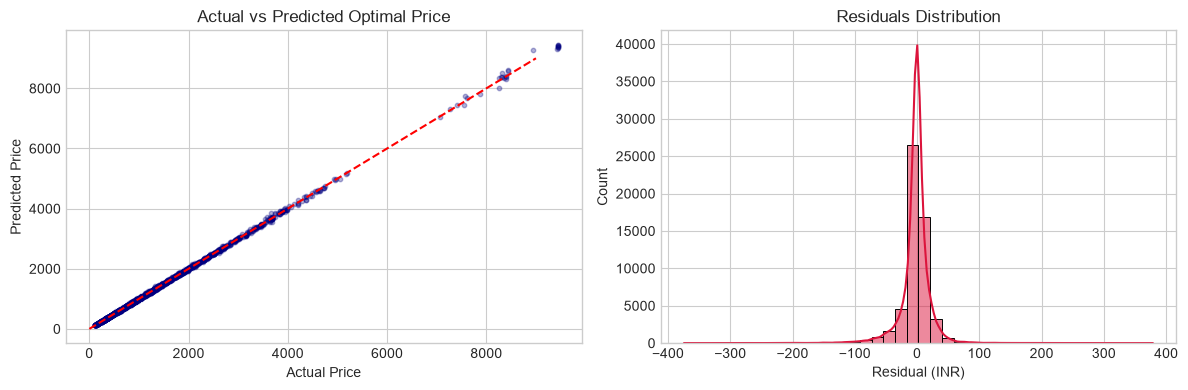

In [23]:
residuals = y_test - y_test_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sample_idx = np.random.choice(len(y_test), 2000, replace=False)
axes[0].scatter(y_test[sample_idx], y_test_pred[sample_idx], alpha=0.3, s=10, color="navy")
axes[0].plot([0, 9000], [0, 9000], "r--")
axes[0].set_title("Actual vs Predicted Optimal Price")
axes[0].set_xlabel("Actual Price")
axes[0].set_ylabel("Predicted Price")

sns.histplot(residuals, bins=40, kde=True, ax=axes[1], color="crimson")
axes[1].set_title("Residuals Distribution")
axes[1].set_xlabel("Residual (INR)")
plt.tight_layout()
plt.show()


In [24]:
test_df = df[test_mask].copy()
test_df["Predicted_Price"] = y_test_pred
test_df["Absolute_Error"] = np.abs(test_df["Optimal_Price"] - test_df["Predicted_Price"])
test_df["Pct_Error"] = (test_df["Absolute_Error"] / test_df["Optimal_Price"]) * 100

test_df.groupby("Category").agg(
    count=("Product_ID", "count"),
    avg_price=("Optimal_Price", "mean"),
    MAE=("Absolute_Error", "mean"),
    MAPE=("Pct_Error", "mean")
).round(2)


,count,avg_price,MAE,MAPE
Category,,,,
Electronics,7704,3193.399902,32.04,1.07
Fashion,7276,1742.459961,24.10,1.51
Footwear,6420,1996.239990,13.52,0.90
Grocery,7704,428.299988,3.92,1.26
Home & Kitchen,7276,1320.569946,8.67,0.82
Mobile Accessories,6420,705.700012,11.48,1.82
Personal Care,6420,722.909973,5.28,0.84
Sports & Fitness,6420,986.669983,11.23,1.39


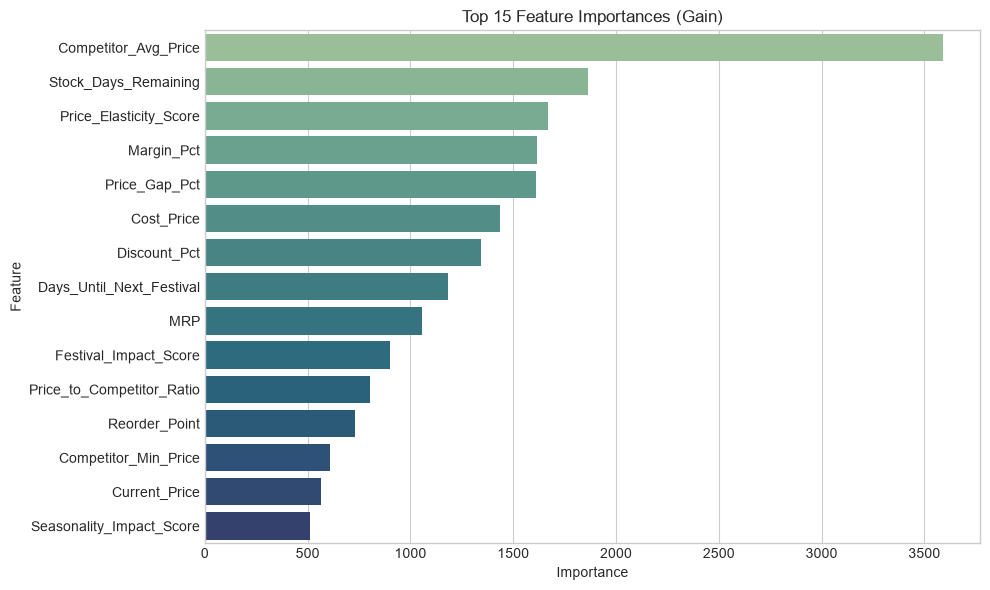

,Feature,Importance
4,Competitor_Avg_Price,3591
16,Stock_Days_Remaining,1865
53,Price_Elasticity_Score,1670
11,Margin_Pct,1617
6,Price_Gap_Pct,1610
0,Cost_Price,1435
10,Discount_Pct,1345
27,Days_Until_Next_Festival,1182
2,MRP,1056
54,Festival_Impact_Score,899


In [25]:
feat_imp = pd.DataFrame({
    "Feature": FEATURE_COLUMNS,
    "Importance": final_model.feature_importances_
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp.head(15), x="Importance", y="Feature", palette="crest")
plt.title("Top 15 Feature Importances (Gain)")
plt.tight_layout()
plt.show()

feat_imp.head(10)


In [26]:
def apply_guardrails(pred_p, cost_p, min_p, max_p, comp_p):
    floor_p = max(min_p, cost_p * 1.05, comp_p * 0.75)
    ceil_p = min(max_p, comp_p * 1.25)
    ceil_p = max(ceil_p, floor_p)
    return round(float(np.clip(pred_p, floor_p, ceil_p)), 2)

sample_test = test_df.sample(5, random_state=42)
rows = []
for _, r in sample_test.iterrows():
    rec_p = apply_guardrails(r["Predicted_Price"], r["Cost_Price"], r["Min_Allowed_Price"], r["Max_Allowed_Price"], r["Competitor_Avg_Price"])
    curr_p = r["Current_Price"]
    diff = rec_p - curr_p
    diff_pct = (diff / curr_p) * 100
    action = "Increase Price" if diff_pct > 2.0 else ("Decrease Price" if diff_pct < -2.0 else "Hold Price")
    rows.append({
        "Product": r["Product_Name"][:30] + "...",
        "Category": r["Category"],
        "Current_Price": curr_p,
        "Competitor_Price": r["Competitor_Avg_Price"],
        "Recommended_Price": rec_p,
        "Change_INR": round(diff, 2),
        "Change_Pct": f"{diff_pct:+.1f}%",
        "Action": action
    })

pd.DataFrame(rows)


,Product,Category,Current_Price,Competitor_Price,Recommended_Price,Change_INR,Change_Pct,Action
0,True Wireless Earbuds with ANC...,Electronics,2339.570068,2170.949951,2669.33,329.76,+14.1%,Increase Price
1,Men Pure Leather Kolhapuri Cha...,Footwear,1081.780029,1099.650024,1374.56,292.78,+27.1%,Increase Price
2,GPS Smartwatch with AMOLED Dis...,Electronics,6627.129883,7240.229980,8398.95,1771.82,+26.7%,Increase Price
3,Men High-Top Basketball Street...,Footwear,2485.649902,2421.020020,3016.88,531.23,+21.4%,Increase Price
4,Organic Turmeric Powder 500g...,Grocery,153.690002,151.259995,188.69,35.00,+22.8%,Increase Price


In [27]:
models_dir = Path("models")
models_dir.mkdir(parents=True, exist_ok=True)

bundle = {
    "model": final_model,
    "feature_columns": FEATURE_COLUMNS,
    "category_mapping": category_mapping,
    "city_mapping": city_mapping,
    "weather_mapping": weather_mapping,
    "competitor_stock_mapping": competitor_stock_mapping,
    "best_params": best_params,
    "metrics": {
        "test_mae": test_metrics["MAE"],
        "test_rmse": test_metrics["RMSE"],
        "test_r2": test_metrics["R2"],
        "test_mape": test_metrics["MAPE (%)"],
        "markup_r2": test_metrics["Markup R2"]
    }
}

with open(models_dir / "price_optimizer.pkl", "wb") as f:
    pickle.dump(bundle, f)

metadata = {
    "model_type": "LightGBM Regressor",
    "features_count": len(FEATURE_COLUMNS),
    "hyperparameters": best_params,
    "performance_metrics": bundle["metrics"]
}

with open(models_dir / "model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved model bundle to models/price_optimizer.pkl")
print("Saved metadata to models/model_metadata.json")


Saved model bundle to models/price_optimizer.pkl
Saved metadata to models/model_metadata.json
